In [1]:
# Parameters (papermill injects these)
MARKET = "aaa_gas_us"
# FAST = True → 3 CV folds per model, for quick checks of the pipeline
FAST = False

In [2]:
# Parameters
MARKET = "high_temp_miami"
FAST = False

In [3]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

from prediction_markets_forecasting import kalshi
from prediction_markets_forecasting.markets import build
from prediction_markets_forecasting.pricing import (
    bracket_label,
    edge_table,
    implied_distribution,
    model_distribution,
)
from prediction_markets_forecasting.selection import discover, select
from prediction_markets_forecasting.specs import get_spec
from prediction_markets_forecasting.stationarity import decide
from prediction_markets_forecasting.tournament import (
    ETS_CONFIGS,
    NIXTLA,
    SARIMAX_CONFIGS,
    run_tournament,
    timed,
)

plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "figure.dpi": 100,
    }
)
pd.set_option("display.width", 200)

spec = get_spec(MARKET)
if FAST:
    for c in spec.freqs.values():
        c.n_folds = 3
AS_OF = pd.Timestamp.now().normalize()
FREQS = list(spec.freqs)
ERR_SCALE, ERR_UNIT = (100, "¢") if spec.units.startswith("$") else (1, spec.units)
OUT = Path("../data/outputs")
OUT.mkdir(parents=True, exist_ok=True)
SNAP = Path("../data/kalshi_snapshots")
SNAP.mkdir(parents=True, exist_ok=True)

display(
    Markdown(
        f"""
# Notebook {spec.number} — {spec.title}

**Family:** {spec.family} &nbsp;|&nbsp; **As of:** {AS_OF:%Y-%m-%d} &nbsp;|&nbsp; **Market key:** `{spec.key}`

**Underlying (X):** {spec.underlying}

| Frequency | Kalshi series | Grid | Season | CV folds (one-step) |
|---|---|---|---|---|
"""
        + "\n".join(
            f"| {k} | `{c.series}` | {c.freq} | {c.season} | {c.n_folds} |"
            for k, c in spec.freqs.items()
        )
    )
)


# Notebook 02 — Daily High Temperature — Miami

**Family:** A weather &nbsp;|&nbsp; **As of:** 2026-09-23 &nbsp;|&nbsp; **Market key:** `high_temp_miami`

**Underlying (X):** Maximum temperature (°F) at USW00012839 for the calendar day, as reported by the NWS climate report / The Weather Company

| Frequency | Kalshi series | Grid | Season | CV folds (one-step) |
|---|---|---|---|---|
| daily | `KXHIGHMIA` | D | 7 | 45 |

---
### Project Overview

Every market in this repo is rendered from **the same notebook**, which follows the pipeline of
*Individual Project — Time Series Analysis & Forecasting (Logitech, MAS 640)*:

| Stage | Description |
|-------|-------------|
| **Part 1** | Data loading & cleaning — the target straight from Kalshi's resolution values, long-history proxy, drivers |
| **Part 2** | EDA — trends, seasonality, size of one-step moves, **driver discovery** |
| **Part 3** | Diagnostics — ADF/KPSS, decomposition, ACF/PACF, **automatic differencing & cointegration** |
| **Part 4** | Tournament — SARIMAX, Log-SARIMAX, SARIMAX-X, ETS, 7 Nixtla, GB/RF (± drivers), baselines, ensemble |
| **Part 5** | Critique & next steps |
| **Part 6** | **Kalshi translation** — forecast distribution → P(each bracket) → edge vs market price after fees |

### How the Kalshi market connects to X
Every contract is a yes/no question on one number on one date: *X > K*, *X < K* or *K₁ ≤ X ≤ K₂*.
The price of "Yes" is the crowd's probability. We forecast X, turn the model's cross-validation errors into a
distribution X ~ N(forecast + bias, σ_CV), compute P(bracket) for every market on the ladder, and compare it
with the price after Kalshi's fee.

### How drivers are chosen (Part 2.6)
1. Economic prior (supply chain, physics) + a **placebo** that must be rejected.
2. Lead-lag correlation of **changes** (never levels): observed drivers must lead by ≥ 1 period; forecasts
   ("ahead" drivers, known before the day) may count at lag 0.
3. Granger causality (p < 0.01), strongest first, skipping near-duplicates (|corr of changes| ≥ 0.9), max 3.
4. Final judge: the same model with vs without drivers in out-of-sample CV (Part 4).

### Stationarity is automatic (Part 3.4)
`d` from ADF + KPSS (both must agree the series is stationary, otherwise difference), `D` from STL seasonal
strength, drivers enter as an error-correction term if cointegrated (Engle-Granger), as changes if not,
as levels only if the target is stationary. AIC only compares SARIMAX orders with the same `d`/`D`;
ML models predict the change when `d ≥ 1`.

---
# Part 1: Data Loading & Cleaning

The market builder (`markets.py`) pulls the exact values each Kalshi event settled on (`expiration_value`),
validates them against a long-history public proxy, and prepares every driver as *the value known at each date*
(no look-ahead).

In [4]:
data = build(spec, AS_OF)
Y, X_by = data.Y, data.X
for title, table in data.reports.items():
    print("=" * 90)
    print(title.upper())
    print("=" * 90)
    display(table.round(4))
for n in data.notes:
    print("•", n)

KALSHI SETTLEMENT DATA QUALITY


,frequency,series,markets,events,foreign_events_dropped,non_numeric_events,clean_obs,start,end
0,daily,KXHIGHMIA,7420,1230,0,75,1155,2023-05-11,2026-09-22


BRIDGE: KALSHI SETTLEMENT VS NOAA STATION RECORD


,overlap_days,exact_match_%,within_1F_%,mean_diff_F,max_abs_diff_F
0,1152,99.566,99.7396,0.0069,5.0


• Target from 2021-04-01 (weather-model archive start); 0 missing days forward-filled.
• Weather-model daily max uses 24 hours of US Eastern *standard* time, matching the NWS climate day (midnight-to-midnight LST, also during daylight saving time).


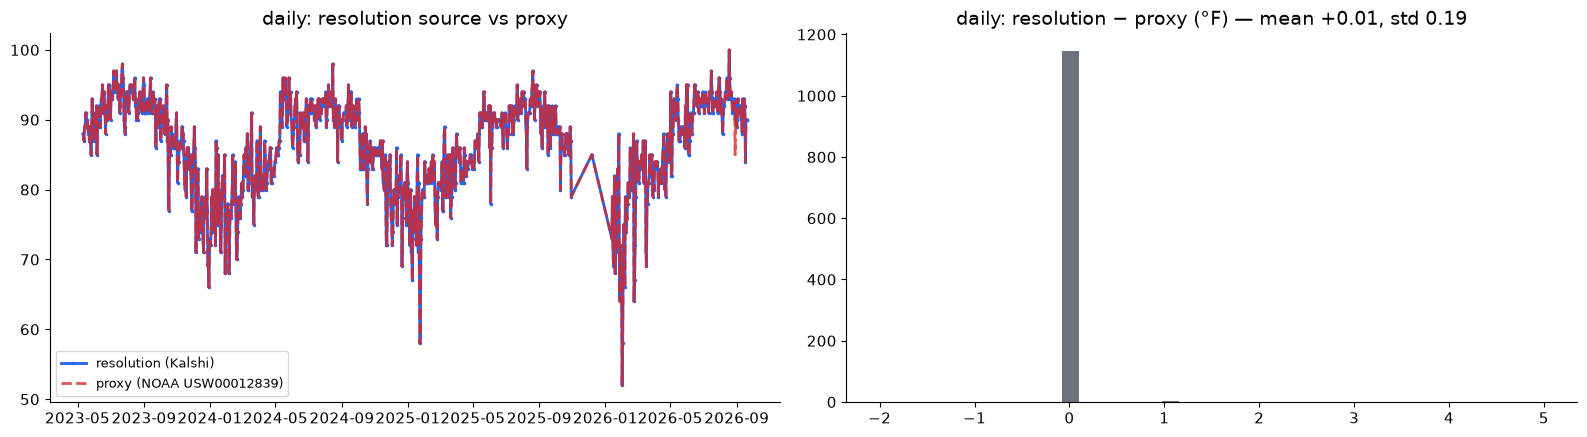

In [5]:
# Resolution source vs long-history proxy
if data.bridges:
    fig, axes = plt.subplots(
        len(data.bridges), 2, figsize=(16, 4.5 * len(data.bridges)), squeeze=False
    )
    for i, (k, b) in enumerate(data.bridges.items()):
        axes[i, 0].plot(
            b.index, b.iloc[:, 0], ".-", color="#2563eb", label=b.columns[0], markersize=3
        )
        axes[i, 0].plot(b.index, b.iloc[:, 1], "--", color="#dc2626", label=b.columns[1], alpha=0.8)
        axes[i, 0].set_title(f"{k}: resolution source vs proxy")
        axes[i, 0].legend(fontsize=9)
        d = (b.iloc[:, 0] - b.iloc[:, 1]) * ERR_SCALE
        axes[i, 1].hist(d, bins=40, color="#6b7280")
        axes[i, 1].set_title(
            f"{k}: resolution − proxy ({ERR_UNIT}) — mean {d.mean():+.2f}, std {d.std():.2f}"
        )
    plt.tight_layout()
    plt.show()

In [6]:
print("=" * 90)
print("FINAL CLEANED DATA SUMMARY")
print("=" * 90)
display(
    pd.DataFrame(
        [
            {
                "frequency": k,
                "kalshi_series": spec.freqs[k].series,
                "n_obs": len(y),
                "start": y.index.min().date(),
                "end": y.index.max().date(),
                "last_value": y.iloc[-1],
                "mean": y.mean(),
                f"std_1step_change_{ERR_UNIT}": y.diff().std() * ERR_SCALE,
                "from_resolution_source_%": (data.source[k].str.contains("Kalshi|AAA")).mean()
                * 100,
            }
            for k, y in Y.items()
        ]
    ).round(3)
)
print("Driver candidates:")
display(data.driver_info)

FINAL CLEANED DATA SUMMARY


,frequency,kalshi_series,n_obs,start,end,last_value,mean,std_1step_change_°F,from_resolution_source_%
0,daily,KXHIGHMIA,2001,2021-04-01,2026-09-22,89.0,85.88,3.423,57.721


Driver candidates:


,description,ahead,start,end,n_obs,days_stale
driver,,,,,,
fcst_gfs_seamless,gfs_seamless daily-max forecast issued the day...,True,2021-04-01,2026-09-24,1981,-1
fcst_ecmwf_ifs025,ecmwf_ifs025 daily-max forecast issued the day...,True,2024-02-04,2026-09-24,964,-1
fcst_icon_seamless,icon_seamless daily-max forecast issued the da...,True,2024-01-20,2026-09-24,974,-1
fcst_gem_seamless,gem_seamless daily-max forecast issued the day...,True,2024-01-20,2026-09-24,975,-1
climo_normal,1991–2020 normal daily max for the calendar da...,True,2021-04-01,2026-09-24,2003,-1
DGS10,10Y Treasury yield — placebo (FRED),False,2021-04-01,2026-09-24,2003,-1


---
# Part 2: Exploratory Data Analysis (EDA)
## 2.1 Target series

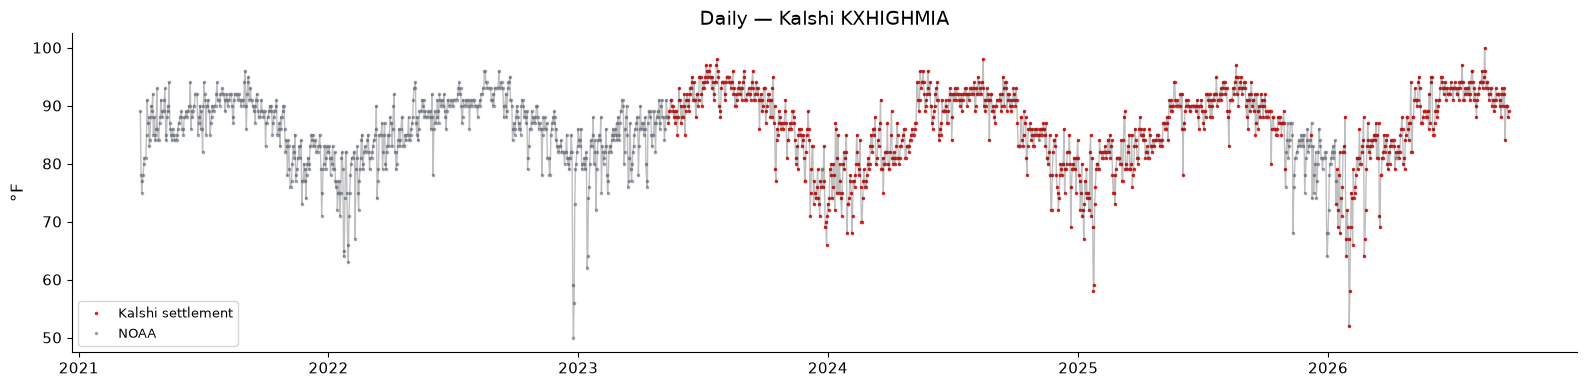

In [7]:
fig, axes = plt.subplots(len(Y), 1, figsize=(16, 4 * len(Y)), squeeze=False)
palette = ["#dc2626", "#9ca3af", "#16a34a", "#2563eb"]
for ax, (k, y) in zip(axes[:, 0], Y.items(), strict=False):
    for (src, idx), color in zip(
        data.source[k].groupby(data.source[k]).groups.items(), palette, strict=False
    ):
        ax.plot(idx, y.loc[idx], ".", markersize=3, color=color, label=src)
    ax.plot(y.index, y.values, color="black", alpha=0.25, linewidth=1)
    ax.set_title(f"{k.capitalize()} — Kalshi {spec.freqs[k].series}")
    ax.set_ylabel(spec.units)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2.2 Target vs its strongest driver candidates (last 3 years)

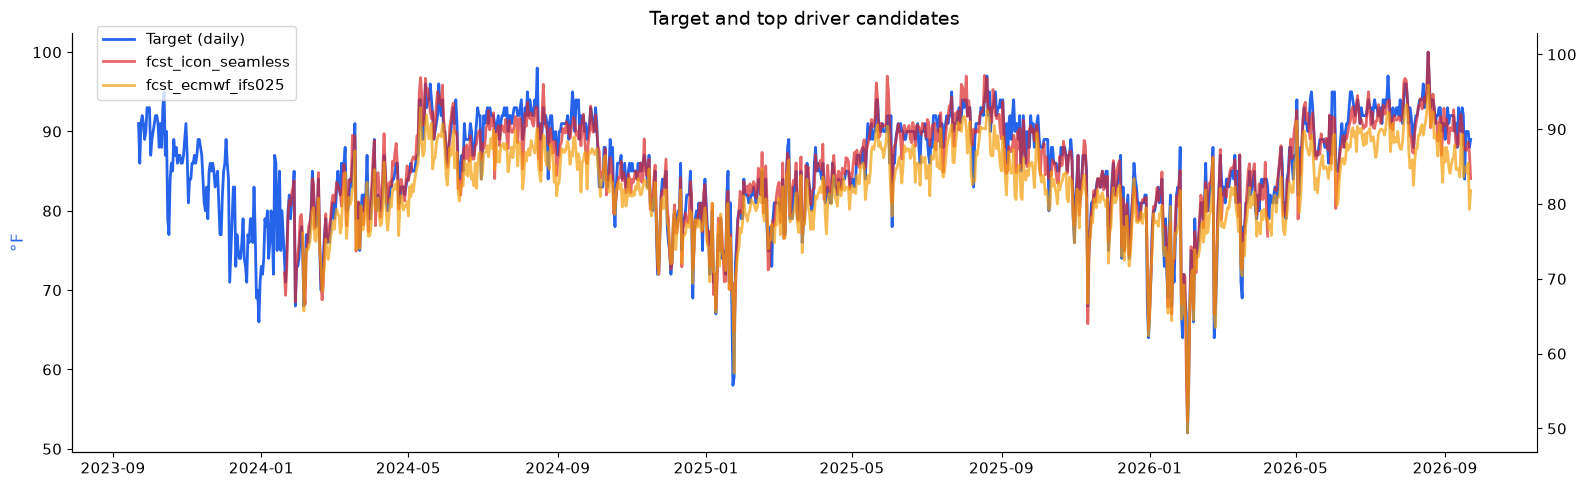

In [8]:
DISC = spec.discovery_freq
yD, XD = Y[DISC], X_by[DISC].reindex(Y[DISC].index)
top = (
    XD.drop(columns=[data.placebo], errors="ignore")
    .corrwith(yD)
    .abs()
    .sort_values(ascending=False)
    .index[:2]
)
recent = yD.index >= yD.index.max() - pd.DateOffset(years=3)
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(yD.index[recent], yD[recent], color="#2563eb", label=f"Target ({DISC})")
ax1.set_ylabel(spec.units, color="#2563eb")
ax2 = ax1.twinx()
for c, color in zip(top, ["#dc2626", "#f59e0b"], strict=False):
    ax2.plot(XD.index[recent], XD[c][recent], color=color, alpha=0.7, label=c)
ax2.spines["right"].set_visible(True)
fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.95))
ax1.set_title("Target and top driver candidates")
plt.tight_layout()
plt.show()

## 2.3 Year-over-Year Growth Rates

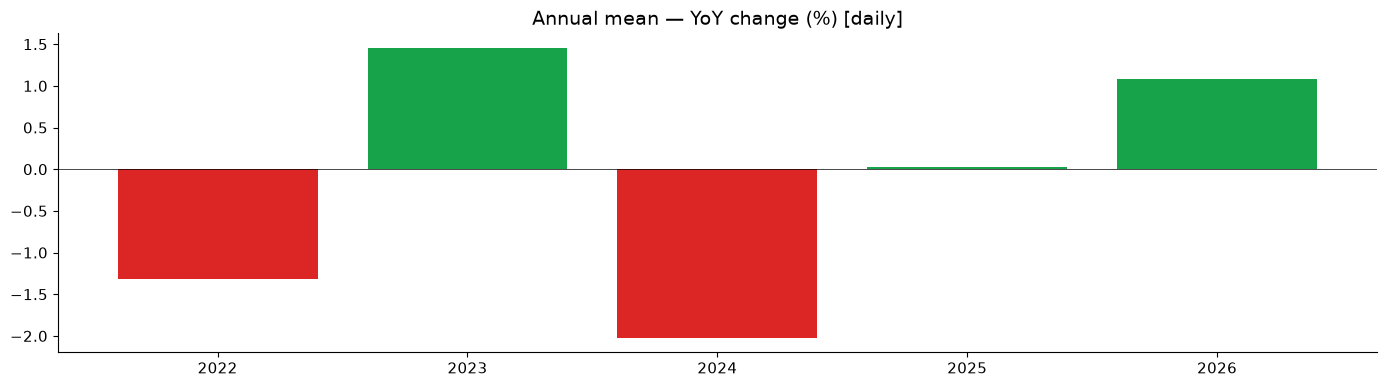

               2021    2022    2023    2024    2025   2026
annual_mean  86.756  85.616  86.866  85.112  85.137  86.06
yoy_%           NaN  -1.300   1.500  -2.000   0.000   1.10


In [9]:
annual = yD.groupby(yD.index.year).mean()
yoy = annual.pct_change() * 100
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(
    yoy.dropna().index,
    yoy.dropna().values,
    color=["#16a34a" if v > 0 else "#dc2626" for v in yoy.dropna()],
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"Annual mean — YoY change (%) [{DISC}]")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"annual_mean": annual.round(3), "yoy_%": yoy.round(1)}).T.to_string())

## 2.4 Seasonality Patterns

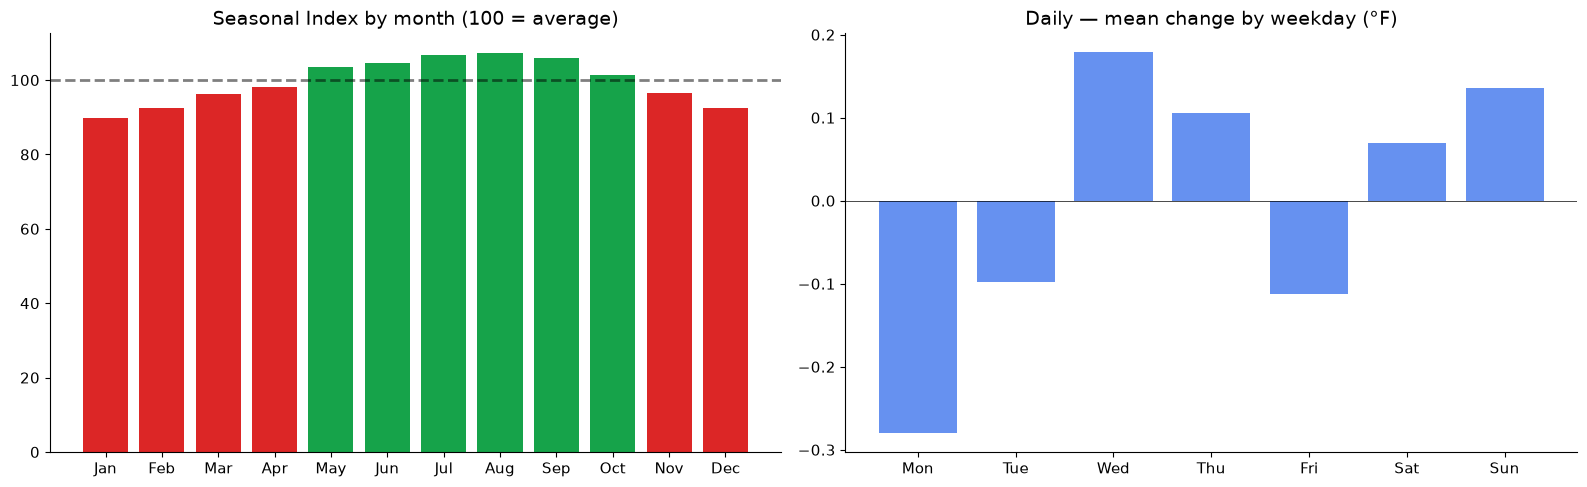

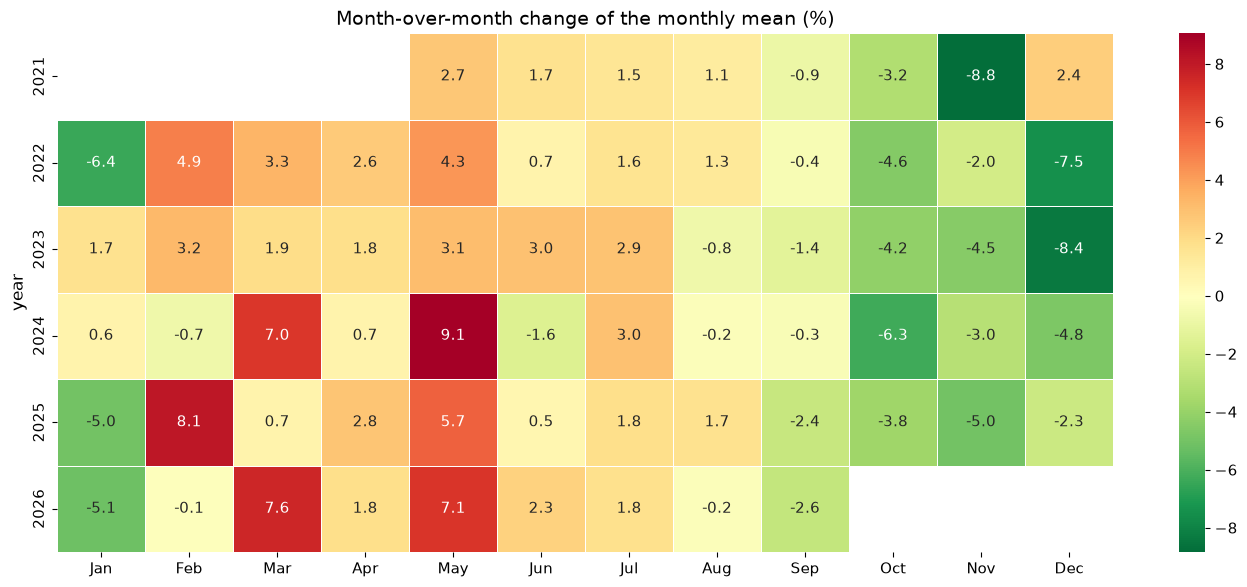

In [10]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_mean = yD.resample("ME").mean()
seasonal_idx = monthly_mean.groupby(monthly_mean.index.month).mean() / monthly_mean.mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(
    seasonal_idx.index,
    seasonal_idx.values,
    color=["#dc2626" if v < 100 else "#16a34a" for v in seasonal_idx],
)
axes[0].axhline(100, color="black", linestyle="--", alpha=0.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title("Seasonal Index by month (100 = average)")
if "daily" in Y:
    dow = Y["daily"].diff().groupby(Y["daily"].index.dayofweek).mean() * ERR_SCALE
    axes[1].bar(
        ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color="#2563eb", alpha=0.7
    )
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_title(f"Daily — mean change by weekday ({ERR_UNIT})")
plt.tight_layout()
plt.show()

heat = monthly_mean.pct_change().mul(100).to_frame("chg")
heat = heat.assign(year=heat.index.year, month=heat.index.month).pivot_table(
    index="year", columns="month", values="chg"
)
heat.columns = [month_names[m - 1] for m in heat.columns]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat.tail(12), annot=True, fmt=".1f", cmap="RdYlGn_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("Month-over-month change of the monthly mean (%)")
plt.tight_layout()
plt.show()

## 2.5 Size of one-step moves (sets how many Kalshi brackets are in play)

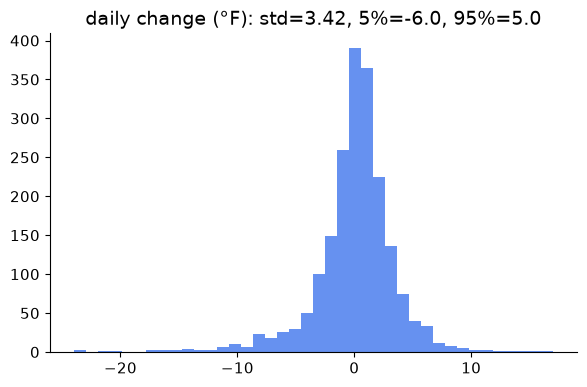

In [11]:
fig, axes = plt.subplots(1, len(Y), figsize=(6 * len(Y), 4), squeeze=False)
for ax, (k, y) in zip(axes[0], Y.items(), strict=False):
    chg = y.diff().dropna() * ERR_SCALE
    ax.hist(chg, bins=40, color="#2563eb", alpha=0.7)
    ax.set_title(
        f"{k} change ({ERR_UNIT}): std={chg.std():.2f}, 5%={chg.quantile(.05):.1f}, 95%={chg.quantile(.95):.1f}"
    )
plt.tight_layout()
plt.show()

## 2.6 Driver discovery — which variables move *before* X?

**(a) Correlation of levels** — shown only to demonstrate why it misleads (trends and seasons correlate with anything).

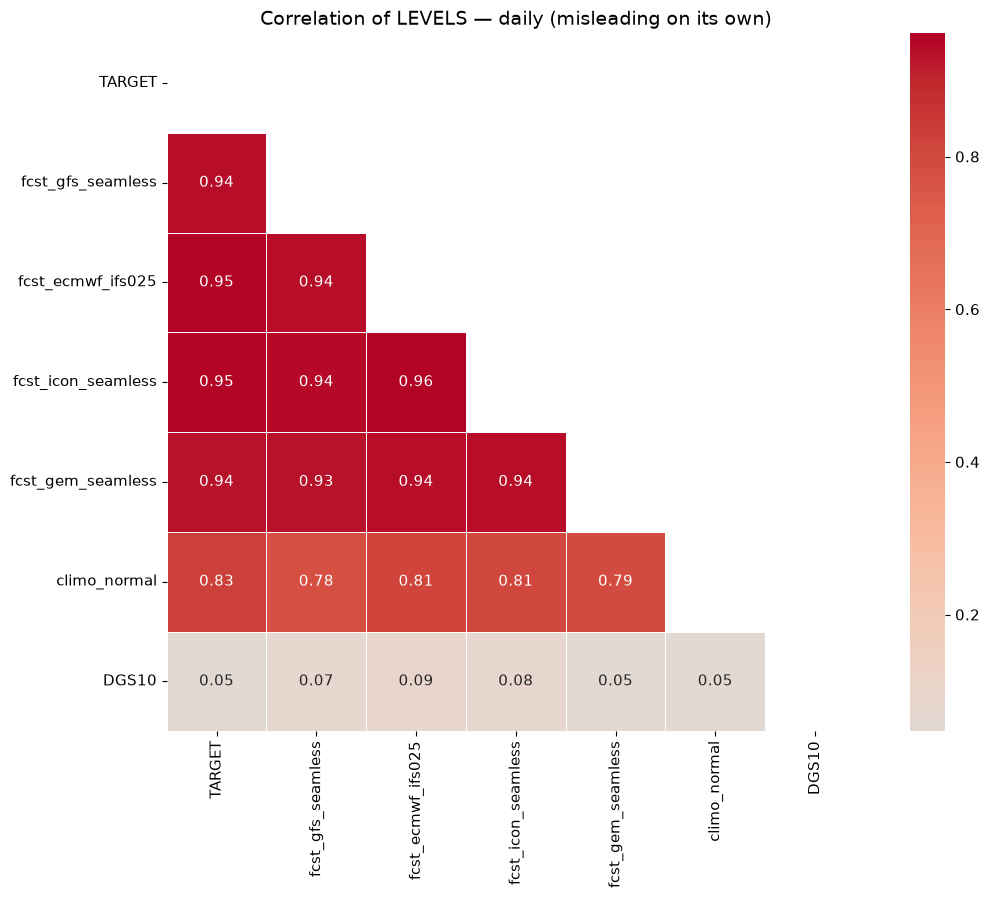

In [12]:
lvl = pd.concat([yD.rename("TARGET"), XD], axis=1).dropna()
fig, ax = plt.subplots(figsize=(11, 9))
corr = lvl.corr()
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f"Correlation of LEVELS — {DISC} (misleading on its own)")
plt.tight_layout()
plt.show()

**(b) Lead-lag correlation of changes** corr(ΔX_t, Δdriver_{t−k}) and **(c) Granger causality**.
Observed drivers must lead by k ≥ 1; forecasts known before the day ("ahead") may count at k = 0.

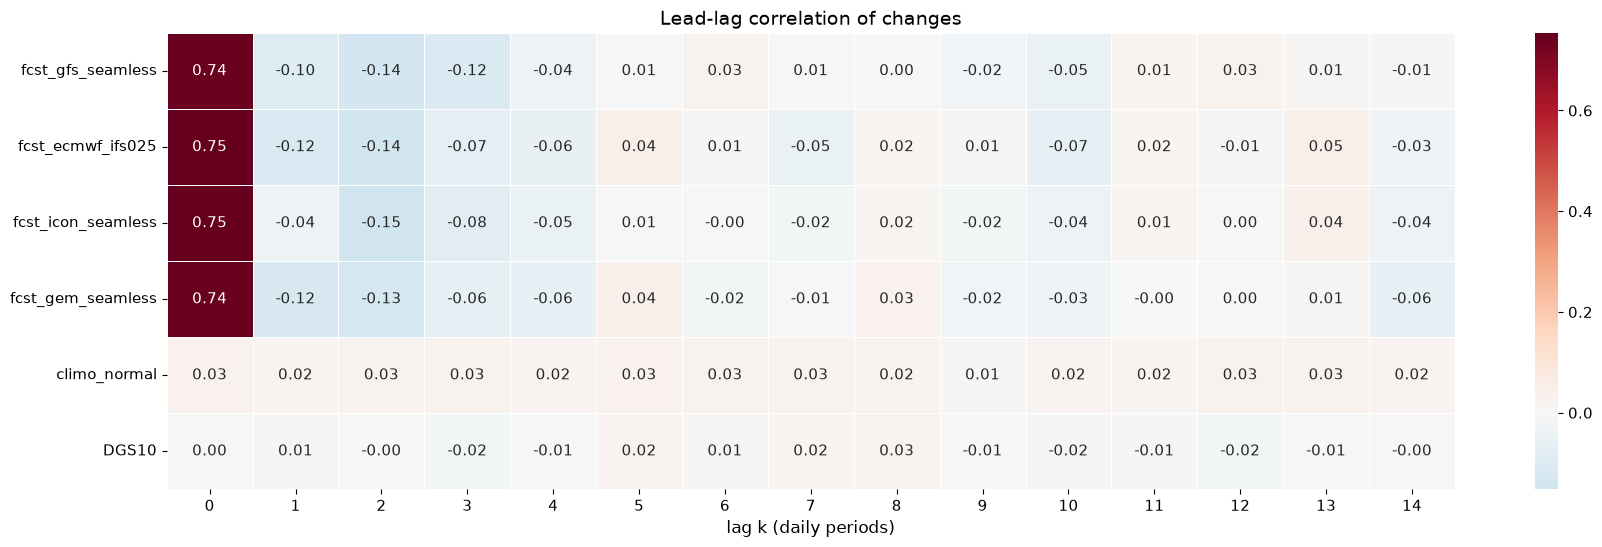

,ahead,level_corr,corr_k0,best_pred_lag,corr_best_pred,granger_p,abs_pred_corr
driver,,,,,,,
fcst_icon_seamless,True,0.9540,0.7536,0,0.7536,0.0000,0.7536
fcst_ecmwf_ifs025,True,0.9529,0.7524,0,0.7524,0.0000,0.7524
fcst_gem_seamless,True,0.9373,0.7436,0,0.7436,0.0000,0.7436
fcst_gfs_seamless,True,0.9374,0.7423,0,0.7423,0.0000,0.7423
climo_normal,True,0.8025,0.0328,0,0.0328,0.0639,0.0328
DGS10,False,0.0099,0.0007,8,0.0263,0.6342,0.0263


In [13]:
MAX_LAG = 14 if DISC == "daily" else 8
drivers_table, cc = discover(yD, XD, data.ahead, MAX_LAG)
fig, ax = plt.subplots(figsize=(min(18, 4 + MAX_LAG), 0.6 * len(cc) + 2))
sns.heatmap(cc, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_xlabel(f"lag k ({DISC} periods)")
ax.set_title("Lead-lag correlation of changes")
plt.tight_layout()
plt.show()
display(drivers_table.round(4))

In [14]:
SELECTED = select(drivers_table, XD)
print("Selected exogenous drivers:")
for c in SELECTED:
    r = drivers_table.loc[c]
    print(
        f'  {c:22s} {"(ahead) " if r["ahead"] else "        "}corr@lag{r["best_pred_lag"]}={r["corr_best_pred"]:+.2f}  '
        f'Granger p={r["granger_p"]:.1e}'
    )
if data.placebo:
    ok = data.placebo not in SELECTED
    print(
        f'\nPlacebo {data.placebo}: Granger p = {drivers_table.loc[data.placebo, "granger_p"]:.3f} → '
        + ("correctly rejected" if ok else "WARNING: selected — the filters are too loose")
    )

Selected exogenous drivers:
  fcst_icon_seamless     (ahead) corr@lag0=+0.75  Granger p=1.7e-217
  fcst_ecmwf_ifs025      (ahead) corr@lag0=+0.75  Granger p=3.2e-210
  fcst_gem_seamless      (ahead) corr@lag0=+0.74  Granger p=2.1e-188

Placebo DGS10: Granger p = 0.634 → correctly rejected


## 2.7 Key EDA Findings

| Question | Where to look |
|---|---|
| Is the long-history proxy faithful to the resolution source? | Part 1 bridge table and plots |
| Which drivers lead X? | 2.6 — lead-lag heatmap and Granger table |
| Is the selection honest? | 2.6 — the placebo must be rejected |
| How wide is the distribution that matters for brackets? | 2.5 — std of one-step changes |

---
# Part 3: Time Series Diagnostics
## 3.1 Stationarity Tests (ADF & KPSS)

In [15]:
rows = []
for k, ts in Y.items():
    adf_p = adfuller(ts.dropna(), autolag="AIC")[1]
    kpss_p = kpss(ts.dropna(), regression="ct")[1]
    adf_d = adfuller(ts.diff().dropna(), autolag="AIC")[1]
    rows.append(
        {
            "series": k,
            "ADF_p": adf_p,
            "ADF": "Stationary" if adf_p < 0.05 else "Non-stationary",
            "KPSS(ct)_p": kpss_p,
            "KPSS": "Non-stationary" if kpss_p < 0.05 else "Stationary",
            "ADF_diff1_p": adf_d,
            "ADF_diff1": "Stationary" if adf_d < 0.05 else "Non-stationary",
        }
    )
display(pd.DataFrame(rows).round(4))

/var/folders/_t/0d6mt48n3y16hqsmzpvwq2dw0000gp/T/ipykernel_32903/3986329203.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(ts.dropna(), regression='ct')[1]


,series,ADF_p,ADF,KPSS(ct)_p,KPSS,ADF_diff1_p,ADF_diff1
0,daily,0.044,Stationary,0.1,Stationary,0.0,Stationary


## 3.2 Seasonal Decomposition

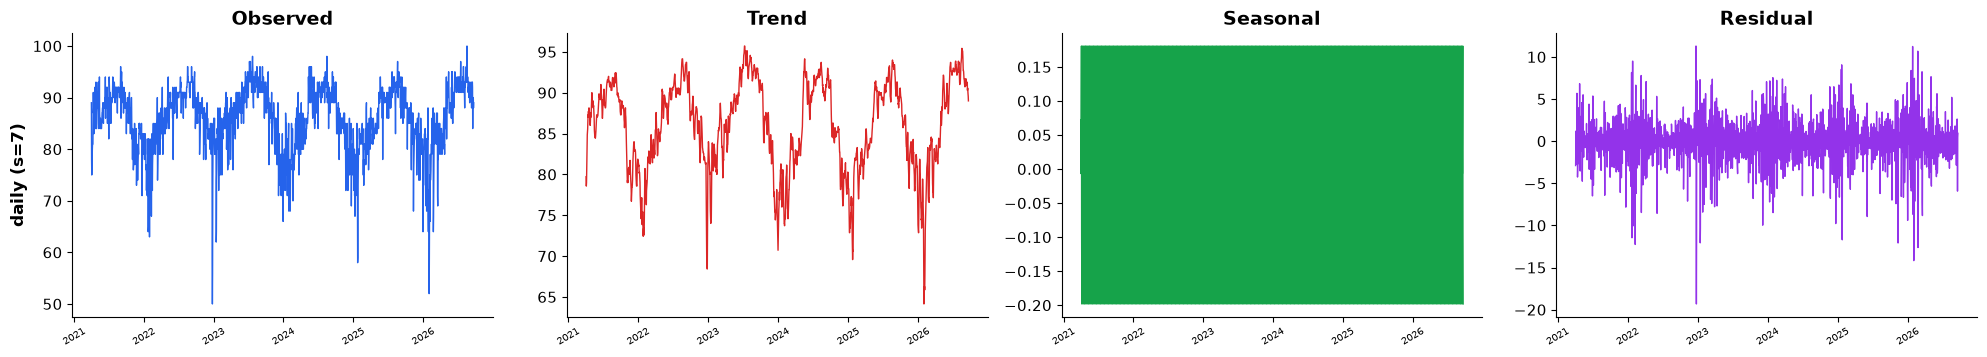

In [16]:
fig, axes = plt.subplots(len(Y), 4, figsize=(20, 3.7 * len(Y)), squeeze=False)
colors = ["#2563eb", "#dc2626", "#16a34a", "#9333ea"]
for i, (k, ts) in enumerate(Y.items()):
    dec = seasonal_decompose(ts, model="additive", period=spec.freqs[k].season)
    for j, ((title, s), color) in enumerate(
        zip(
            [
                ("Observed", dec.observed),
                ("Trend", dec.trend),
                ("Seasonal", dec.seasonal),
                ("Residual", dec.resid),
            ],
            colors,
            strict=False,
        )
    ):
        axes[i, j].plot(s.index, s.values, color=color, linewidth=1)
        if i == 0:
            axes[i, j].set_title(title, fontweight="bold")
        axes[i, j].tick_params(axis="x", rotation=30, labelsize=7)
    axes[i, 0].set_ylabel(f"{k} (s={spec.freqs[k].season})", fontweight="bold")
plt.tight_layout()
plt.show()

## 3.3 ACF & PACF Analysis

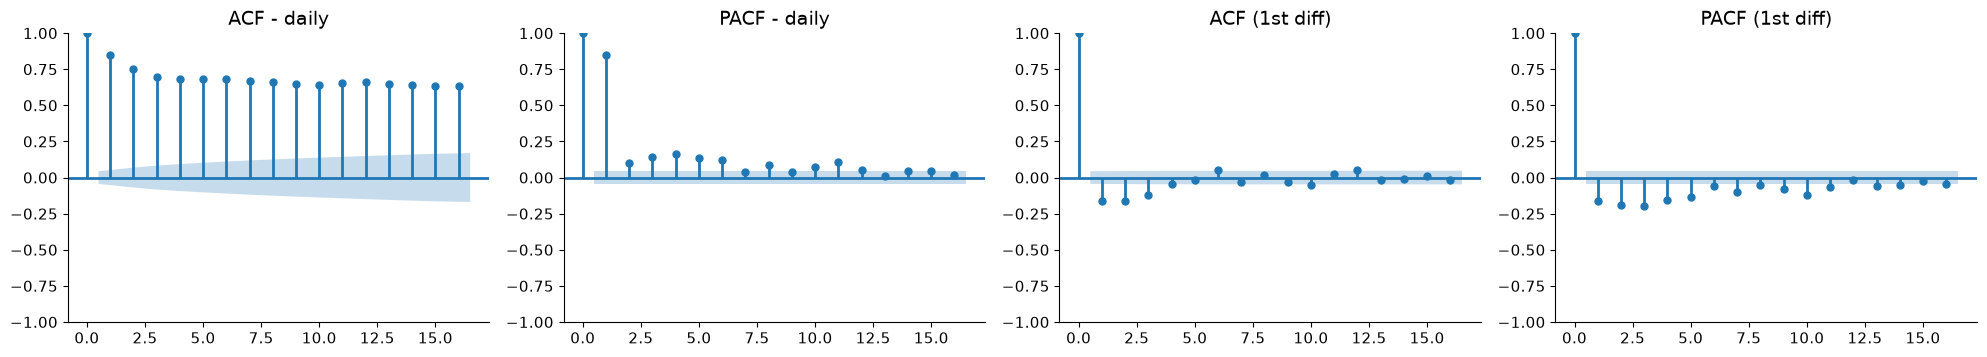

In [17]:
fig, axes = plt.subplots(len(Y), 4, figsize=(20, 3.7 * len(Y)), squeeze=False)
for i, (k, ts) in enumerate(Y.items()):
    lags = min(2 * spec.freqs[k].season + 2, len(ts) // 2 - 1, 60)
    plot_acf(ts, ax=axes[i, 0], lags=lags, title=f"ACF - {k}")
    plot_pacf(ts, ax=axes[i, 1], lags=lags, title=f"PACF - {k}")
    plot_acf(ts.diff().dropna(), ax=axes[i, 2], lags=lags, title="ACF (1st diff)")
    plot_pacf(ts.diff().dropna(), ax=axes[i, 3], lags=lags, title="PACF (1st diff)")
plt.tight_layout()
plt.show()

## 3.4 Automatic Differencing & Cointegration Decisions

Computed, not chosen by hand — every model in Part 4 follows this table.

| Decision | Rule |
|---|---|
| `d` | Difference until ADF rejects a unit root **and** KPSS does not reject stationarity; if they disagree, difference |
| `D` | One seasonal difference if STL seasonal strength F_s > 0.64 |
| exog mode | **ecm**: Engle-Granger cointegrated → error-correction term + driver changes · **diff**: changes only · **level**: target stationary → driver levels |

In [18]:
DESIGN = {
    k: decide(
        Y[k],
        X_by[k][SELECTED],
        spec.freqs[k].season,
        ahead=[c for c in SELECTED if c in data.ahead],
    )
    for k in FREQS
}
display(pd.DataFrame({k: v.summary() for k, v in DESIGN.items()}).T)

,d,d_log,D,seasonal_strength,ADF_p,KPSS_p,exog_mode,ecm_driver
daily,0,0,0,0.077,0.044,0.1,level,None


---
# Part 4: Forecasting Tournament

| Family | Model | Selection | Key idea |
|---|---|---|---|
| **Statistical** | SARIMAX / Log-SARIMAX | Automatic `d`,`D` → AIC over (p,q,P,Q) → CV | Autocorrelation + seasonality |
| **Statistical** | SARIMAX-X | Same order on the differenced target + ECM / driver regressors | Drivers without spurious levels |
| **Statistical** | ETS (10 configs) | CV | Exponential smoothing |
| **Nixtla** | AutoARIMA, AutoETS, AutoTheta, AutoCES, DynOptTheta, OptTheta, MSTL | Automatic + CV | Different dynamics |
| **ML** | Gradient Boosting, Random Forest (± drivers) | CV | Lags, rolling stats, calendar; change target when `d ≥ 1` |
| **Baseline** | Naive, Seasonal Naive, Drift | CV | Naive = random walk: the bar to beat |
| **Ensemble** | Mean of best per family | CV on member predictions | Diversity |

**CV:** expanding window, one-step-ahead, pooled RMSE. **Skill vs Naive** = 1 − RMSE / RMSE_Naive.

In [19]:
print(
    f"SARIMAX orders: {len(SARIMAX_CONFIGS)} | ETS: {len(ETS_CONFIGS)} | Nixtla: {len(NIXTLA)} | "
    f"ML: 2 (+ driver variants) | Drivers: {SELECTED}"
)
T = {}
for k in FREQS:
    print(f'\n{"=" * 70}\n{k.upper()} — {spec.freqs[k].series}\n{"=" * 70}')
    T[k] = timed(run_tournament, Y[k], X_by[k], spec.freqs[k], DESIGN[k])

SARIMAX orders: 24 | ETS: 10 | Nixtla: 7 | ML: 2 (+ driver variants) | Drivers: ['fcst_icon_seamless', 'fcst_ecmwf_ifs025', 'fcst_gem_seamless']

DAILY — KXHIGHMIA
Length: 962 | 2024-02-04 → 2026-09-22 | next target date: 2026-09-23
  Automatic design: d=0, d_log=0, D=0, exog mode=level | ahead drivers: ['fcst_icon_seamless', 'fcst_ecmwf_ifs025', 'fcst_gem_seamless']


  SARIMAX: 19 orders with d=0, D=0 → best AIC (2, 0, 2)x(1, 0, 1, 7) (AIC=4912.0)


  LogSARIMAX: 19 orders with d=0, D=0 → best AIC (2, 0, 2)x(0, 0, 1, 7) (AIC=-3404.6)


  Nixtla: 7/7 models evaluated


  >> Best CV: GradientBoosting-X (RMSE=1.739, MAPE=1.41%, skill vs Naive=+28.1%) → next = 86.7247
  (328s)


## 4.1 Model Rankings & Comparison

In [20]:
summary = pd.DataFrame(
    [
        {
            "frequency": k,
            "kalshi": spec.freqs[k].series,
            "best_model": t.best,
            "type": t.ranking.iloc[0]["Type"],
            f"CV_RMSE_{ERR_UNIT}": t.ranking.iloc[0]["CV_RMSE"] * ERR_SCALE,
            f"Naive_RMSE_{ERR_UNIT}": t.ranking.set_index("Model").loc["Naive", "CV_RMSE"]
            * ERR_SCALE,
            "skill_vs_naive": t.ranking.iloc[0]["Skill_vs_Naive"],
            "MAPE_%": t.ranking.iloc[0]["MAPE"],
            "next_date": t.next_date.date(),
            "forecast": t.ranking.iloc[0]["Forecast"],
        }
        for k, t in T.items()
    ]
)
print("=" * 100)
print("BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE")
print("=" * 100)
display(summary.round(4))
for k, t in T.items():
    r = t.ranking.assign(**{f"CV_RMSE_{ERR_UNIT}": t.ranking["CV_RMSE"] * ERR_SCALE})
    print(f"\n{k.upper()} — full ranking")
    print(
        r[
            [
                "Model",
                "Type",
                "Exog",
                f"CV_RMSE_{ERR_UNIT}",
                "MAPE",
                "Skill_vs_Naive",
                "n_cv",
                "Forecast",
            ]
        ]
        .round(4)
        .to_string()
    )

BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE


,frequency,kalshi,best_model,type,CV_RMSE_°F,Naive_RMSE_°F,skill_vs_naive,MAPE_%,next_date,forecast
0,daily,KXHIGHMIA,GradientBoosting-X,ML,1.7393,2.4175,0.2805,1.4076,2026-09-23,86.7247



DAILY — full ranking
                                     Model        Type   Exog  CV_RMSE_°F    MAPE  Skill_vs_Naive  n_cv  Forecast
1                       GradientBoosting-X          ML   True      1.7393  1.4076          0.2805    45   86.7247
2   SARIMAX-X[level](2, 0, 2)x(1, 0, 1, 7)     SARIMAX   True      1.8984  1.6703          0.2147    45   87.7191
3                           RandomForest-X          ML   True      1.9360  1.6024          0.1992    45   86.8679
4                                 Ensemble    Ensemble   True      1.9826  1.4618          0.1799    45   88.6520
5                         GradientBoosting          ML  False      2.0584  1.4921          0.1485    45   89.0450
6            SARIMAX(2, 0, 2)x(1, 0, 1, 7)     SARIMAX  False      2.1312  1.6060          0.1184    45   89.5801
7                           Nixtla_AutoETS      Nixtla  False      2.1377  1.5723          0.1158    45   88.8951
8                             RandomForest          ML  False     

### Does adding the drivers help? (same model, same folds; negative Δ = better)

In [21]:
rows = []
for k, t in T.items():
    r = t.ranking.set_index("Model")["CV_RMSE"]
    for base, with_x in [
        ("SARIMAX(", "SARIMAX-X"),
        ("GradientBoosting", "GradientBoosting-X"),
        ("RandomForest", "RandomForest-X"),
    ]:
        a = [m for m in r.index if m.startswith(base) and "-X" not in m]
        b = [m for m in r.index if m.startswith(with_x)]
        if a and b:
            rows.append(
                {
                    "frequency": k,
                    "model": base.rstrip("("),
                    f"without_{ERR_UNIT}": r[a[0]] * ERR_SCALE,
                    f"with_X_{ERR_UNIT}": r[b[0]] * ERR_SCALE,
                    f"Δ_{ERR_UNIT}": (r[b[0]] - r[a[0]]) * ERR_SCALE,
                    "improves": r[b[0]] < r[a[0]],
                }
            )
display(pd.DataFrame(rows).round(3))

,frequency,model,without_°F,with_X_°F,Δ_°F,improves
0,daily,SARIMAX,2.131,1.898,-0.233,True
1,daily,GradientBoosting,2.058,1.739,-0.319,True
2,daily,RandomForest,2.151,1.936,-0.215,True


In [22]:
tiers = pd.DataFrame(
    [
        {
            "frequency": k,
            "best_model": t.best,
            "family": t.ranking.iloc[0]["Type"],
            "MAPE_%": t.ranking.iloc[0]["MAPE"],
            "tier": pd.cut(
                [t.ranking.iloc[0]["MAPE"]],
                [0, 10, 20, 50, np.inf],
                labels=["Good (<10%)", "Acceptable (10-20%)", "Poor (20-50%)", "Unreliable (>50%)"],
            )[0],
            "beats_naive": t.ranking.iloc[0]["Skill_vs_Naive"] > 0,
        }
        for k, t in T.items()
    ]
)
print(
    "MAPE tiers as in the original notebook — for prices/temperatures the real test is skill vs Naive."
)
display(tiers.round(3))

MAPE tiers as in the original notebook — for prices/temperatures the real test is skill vs Naive.


,frequency,best_model,family,MAPE_%,tier,beats_naive
0,daily,GradientBoosting-X,ML,1.408,Good (<10%),True


## 4.2 Forecast Visualization

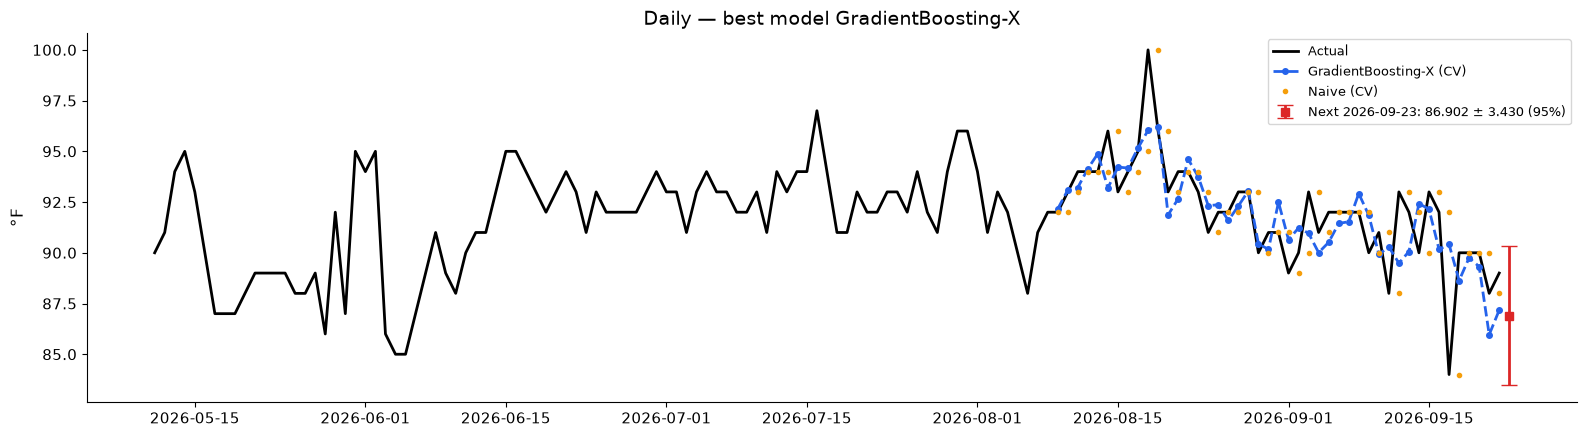

In [23]:
fig, axes = plt.subplots(len(T), 1, figsize=(16, 4.5 * len(T)), squeeze=False)
for ax, (k, t) in zip(axes[:, 0], T.items(), strict=False):
    b = t.best
    w = t.ts.iloc[-3 * spec.freqs[k].n_folds :]
    ax.plot(w.index, w.values, color="black", label="Actual")
    ax.plot(
        t.cv_pred[b].index,
        t.cv_pred[b].values,
        "o--",
        color="#2563eb",
        markersize=4,
        label=f"{b} (CV)",
    )
    ax.plot(
        t.cv_pred["Naive"].index,
        t.cv_pred["Naive"].values,
        ".",
        color="#f59e0b",
        label="Naive (CV)",
    )
    mu, sd = model_distribution(t.cv_err[b], t.forecasts[b])
    ax.errorbar(
        [t.next_date],
        [mu],
        yerr=[[1.96 * sd], [1.96 * sd]],
        fmt="s",
        color="#dc2626",
        capsize=6,
        label=f"Next {t.next_date:%Y-%m-%d}: {mu:.3f} ± {1.96 * sd:.3f} (95%)",
    )
    ax.set_title(f"{k.capitalize()} — best model {b}")
    ax.set_ylabel(spec.units)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4.3 Export Forecast Data

In [24]:
for k, t in T.items():
    t.ranking.to_csv(OUT / f"{spec.number}_{spec.key}_{k}_ranking_{AS_OF:%Y%m%d}.csv")
summary.to_csv(OUT / f"{spec.number}_{spec.key}_summary_{AS_OF:%Y%m%d}.csv", index=False)
print(f"Saved to {OUT.resolve()}")

Saved to /Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/data/outputs


---
# Part 5: Critique & Next Steps

## Strengths of the Approach

| Strength | Detail |
|---|---|
| **Target = resolution source** | Kalshi's own `expiration_value`, validated against a long-history public record |
| **Honest driver selection** | Lead-lag on changes + Granger + placebo + with/without out-of-sample test |
| **No look-ahead** | Observed drivers lagged; only forecasts issued before the day enter at t |
| **Automatic stationarity** | `d`, `D` and the exog mode come from tests, identical in every notebook |
| **Same tournament for every market** | 14+ model types across 5 families; each frequency picks its own winner |
| **Random-walk benchmark** | Every model judged by skill vs Naive |

In [25]:
display(
    Markdown(
        "## Limitations (market-specific)\n\n| Limitation | Impact | Potential Mitigation |\n|---|---|---|\n"
        + "\n".join(f"| {a} | {b} | {c} |" for a, b, c in spec.limitations)
        + "\n| **No backtest vs historical Kalshi prices** | Part 6 edges are live signals, not proven P&L "
        "| Replay Kalshi candlesticks: model probability vs price at bet time |"
    )
)

## Limitations (market-specific)

| Limitation | Impact | Potential Mitigation |
|---|---|---|
| Only day-before model runs | Morning-of runs (fresher) are not used | Add Open-Meteo previous_day0 / HRRR for same-day bets |
| Normal errors | Convective days (sea breeze, storms) have fatter tails | Empirical / Student-t errors by season |
| Station vs grid point | Model grid cells average land and sea near the coast | The tournament's bias correction (ECM / regression) learns the station offset |
| Market already sees the day | Once the event day starts, observations beat forecasts | Bet the evening before or early morning; compare with live METAR |
| **No backtest vs historical Kalshi prices** | Part 6 edges are live signals, not proven P&L | Replay Kalshi candlesticks: model probability vs price at bet time |

---
# Part 6: Kalshi Translation — Forecast → Probability → Edge

1. **Model:** best model of the matching frequency, X ~ N(forecast + mean CV error, σ of CV errors) for events
   up to 3 periods ahead (recursive forecast; σ scaled by √h beyond one step — an approximation).
2. **Nowcast (when a finer series exists):** random walk from the latest fine observation with the empirical
   σ of h-step changes — the freshest information.
3. **Market:** mid-price of each bracket; its implied mean and σ are recovered from the whole ladder.
4. **Edge** = P − price − fee (≈ 0.07·P·(1−P)). A candidate needs edge > 3¢, and the nowcast must agree when it exists.

In [26]:
stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
now_series = Y.get(spec.nowcast_freq) if spec.nowcast_freq else None
EDGES, SHARP = {}, []
for k in FREQS:
    t, cfg = T[k], spec.freqs[k]
    lad = kalshi.ladder(cfg.series)
    if lad.empty:
        print(f"{k}: no open markets")
        continue
    lad.to_csv(SNAP / f"{cfg.series}_{stamp}.csv", index=False)
    model = model_distribution(t.cv_err[t.best], t.forecasts[t.best])
    frames = []
    for ev, g in lad.groupby("event_date"):
        h = t.steps_to(ev)
        on_model = 1 <= h <= 3
        if on_model:
            path = t.forecast_path(t.best, h)
            dist = (path[-1] + np.mean(t.cv_err[t.best]), model[1] * np.sqrt(h))
        now = None
        if now_series is not None:
            h = (ev - now_series.index[-1]).days
            if h > 0:
                now = (float(now_series.iloc[-1]), float(max(now_series.diff(h).std(ddof=1), 1e-3)))
        et = edge_table(g, spec.integer, dist if on_model else None, now)
        et["bracket"] = [bracket_label(r) for _, r in et.iterrows()]
        et["on_model_date"] = on_model
        et["h"] = h
        if ev <= AS_OF:  # the event day has started: the market already sees observations
            et["signal"] = ""
        frames.append(et)
        mu_m, sd_m = implied_distribution(g, spec.integer)
        SHARP.append(
            {
                "frequency": k,
                "event": ev.date(),
                "event_started": ev <= AS_OF,
                "market_mu": mu_m,
                "market_sigma": sd_m,
                "h": h,
                "model_mu": dist[0] if on_model else np.nan,
                "model_sigma": dist[1] if on_model else np.nan,
                "nowcast_mu": now[0] if now else np.nan,
                "nowcast_sigma": now[1] if now else np.nan,
            }
        )
    EDGES[k] = pd.concat(frames)
    print(
        f'\n{"=" * 110}\n{k.upper()} {cfg.series} — best {t.best}: one-step μ={model[0]:.4f}, σ={model[1]:.4f} '
        f'for {t.next_date:%Y-%m-%d}\n{"=" * 110}'
    )
    cols = [
        "bracket",
        "yes_bid",
        "yes_ask",
        "no_ask",
        "mid",
        "p_model",
        "p_now",
        "edge_yes_model",
        "edge_no_model",
        "edge_yes_now",
        "edge_no_now",
        "signal",
        "volume",
    ]
    for ev, g in EDGES[k].groupby("event_date"):
        live = g[(g["mid"].between(0.02, 0.98)) | (g["p_model"].between(0.02, 0.98))]
        tag = (
            f'  [h={g["h"].iloc[0]}]'
            if g["on_model_date"].iloc[0]
            else "  [beyond 3 periods → nowcast only]"
        )
        tag += "  [EVENT DAY ALREADY STARTED — the market sees observations]" if ev <= AS_OF else ""
        print(f"\nEvent {ev:%Y-%m-%d}{tag}")
        print(live[cols].round(3).to_string(index=False))


DAILY KXHIGHMIA — best GradientBoosting-X: one-step μ=86.9020, σ=1.7498 for 2026-09-23

Event 2026-09-23  [h=1]  [EVENT DAY ALREADY STARTED — the market sees observations]
bracket  yes_bid  yes_ask  no_ask   mid  p_model  p_now  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now signal   volume
  82–83     0.99     1.00    0.01 0.995    0.025    NaN          -0.975          0.964           NaN          NaN        45900.46
  84–85     0.00     0.01    1.00 0.005    0.186    NaN           0.175         -0.186           NaN          NaN        38875.41
  86–87     0.00     0.01    1.00 0.005    0.422    NaN           0.412         -0.422           NaN          NaN        30122.11
  88–89     0.00     0.01    1.00 0.005    0.297    NaN           0.287         -0.297           NaN          NaN        28532.76
   > 89     0.00     0.01    1.00 0.005    0.069    NaN           0.058         -0.069           NaN          NaN        20013.24

Event 2026-09-24  [h=2]
bracket  yes_bid  yes_

### Sanity check — how confident is the market compared with us?
If the market's σ is much smaller than ours, the market has information our models lack; a disagreement is then
far more likely *our* blind spot than an edge.

,frequency,event,event_started,market_mu,market_sigma,h,model_mu,model_sigma,nowcast_mu,nowcast_sigma,model_vs_market_sigma
0,daily,2026-09-23,True,82.588,0.775,1,86.902,1.750,NaN,NaN,2.259
1,daily,2026-09-24,False,90.214,2.097,2,89.043,2.475,NaN,NaN,1.180


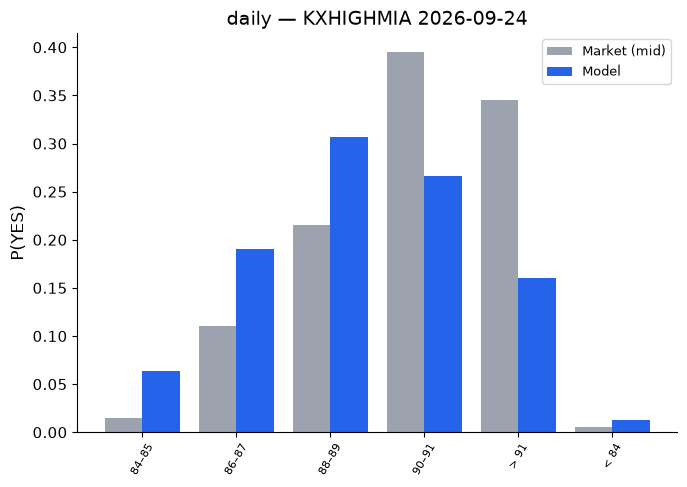

In [27]:
sharp = pd.DataFrame(SHARP)
sharp["model_vs_market_sigma"] = sharp["model_sigma"] / sharp["market_sigma"]
display(sharp.round(3))

evs = [(k, e) for k, e in EDGES.items() if e["on_model_date"].any()]
if evs:
    fig, axes = plt.subplots(1, len(evs), figsize=(7 * len(evs), 5), squeeze=False)
    for ax, (k, e) in zip(axes[0], evs, strict=False):
        g = e[e["on_model_date"] & (e["event_date"] > AS_OF)]
        g = (g if len(g) else e[e["on_model_date"]]).copy()
        g = g[g["event_date"] == g["event_date"].min()]
        x = np.arange(len(g))
        ax.bar(x - 0.2, g["mid"], 0.4, color="#9ca3af", label="Market (mid)")
        ax.bar(x + 0.2, g["p_model"], 0.4, color="#2563eb", label="Model")
        ax.set_xticks(x)
        ax.set_xticklabels(g["bracket"], rotation=60, fontsize=8)
        ax.set_title(f'{k} — {spec.freqs[k].series} {g["event_date"].iloc[0]:%Y-%m-%d}')
        ax.set_ylabel("P(YES)")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [28]:
signals = pd.concat(EDGES.values()) if EDGES else pd.DataFrame()
signals = signals[signals.get("signal", pd.Series(dtype=str)) != ""] if len(signals) else signals
print("=" * 90)
print(f"CANDIDATE SIGNALS — {pd.Timestamp.now():%Y-%m-%d %H:%M}")
print("=" * 90)
wide = sharp[sharp["model_vs_market_sigma"] > 2]
if len(wide):
    print("WARNING — our σ is more than 2x the market-implied σ for:")
    print(
        wide[["frequency", "event", "market_mu", "market_sigma", "model_mu", "model_sigma"]]
        .round(3)
        .to_string(index=False)
    )
    print('Treat "edges" on these events as information gaps, not bets.\n')
started = sharp[sharp["event_started"]]
if len(started):
    print(
        f"NOTE — {len(started)} event(s) already started: the market sees today's observations.\n"
    )
if signals.empty:
    print("None.")
else:
    print(
        signals[
            [
                "ticker",
                "bracket",
                "yes_ask",
                "no_ask",
                "p_model",
                "p_now",
                "edge_yes_model",
                "edge_no_model",
                "signal",
                "volume",
            ]
        ]
        .round(3)
        .to_string(index=False)
    )
print(
    "\nNot validated against historical Kalshi prices yet — research signal, not a bet-sizing rule."
)

CANDIDATE SIGNALS — 2026-09-23 22:41
WARNING — our σ is more than 2x the market-implied σ for:
frequency      event  market_mu  market_sigma  model_mu  model_sigma
    daily 2026-09-23     82.588         0.775    86.902         1.75
Treat "edges" on these events as information gaps, not bets.

NOTE — 1 event(s) already started: the market sees today's observations.

                 ticker bracket  yes_ask  no_ask  p_model  p_now  edge_yes_model  edge_no_model  signal  volume
KXHIGHMIA-26SEP24-B84.5   84–85     0.02    0.99    0.064    NaN           0.042         -0.054 BUY YES 1514.48
KXHIGHMIA-26SEP24-B86.5   86–87     0.12    0.90    0.190    NaN           0.063         -0.097 BUY YES 3158.83
KXHIGHMIA-26SEP24-B88.5   88–89     0.22    0.79    0.307    NaN           0.075         -0.108 BUY YES 4099.28
KXHIGHMIA-26SEP24-B90.5   90–91     0.40    0.61    0.266    NaN          -0.150          0.107  BUY NO 2673.91
  KXHIGHMIA-26SEP24-T91    > 91     0.35    0.66    0.160    NaN       